<a href="https://colab.research.google.com/github/EnDFLab/EMCS_Project/blob/smart_meter_data_analytics/smart_meter_data_visualization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [73]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt  # Import the pyplot submodule
import datetime as dt
import matplotlib.dates as mdates #mdates helps format and manage date-based axes efficiently.
import seaborn as sns # seaborn for heatmap

In [4]:
df = pd.read_csv('https://github.com/EnDFLab/EMCS_Project/raw/refs/heads/smart_meter_data_analytics/data_with_one_hot_encoding/physics_with_one_hot_encoding.csv')

In [12]:
df2 = df.copy()
df2 = df2.dropna()
df2.set_index('timestamp', inplace=True)

#dtype for index column is object so it need to be converted to dataetime object for ploting
df2.index = pd.to_datetime(df2.index)


                 timestamp  Load_consumed (kWh)  air_temp  holiday  Sunday  \
1      2024-01-01 00:15:00                 0.00      8.00        0       0   
2      2024-01-01 00:30:00                 0.00      8.00        0       0   
3      2024-01-01 00:45:00                 0.00      8.00        0       0   
4      2024-01-01 01:00:00                 0.00      8.00        0       0   
5      2024-01-01 01:15:00                 0.00      8.00        0       0   
...                    ...                  ...       ...      ...     ...   
35036  2024-12-30 23:00:00                 0.10      8.00        0       0   
35037  2024-12-30 23:15:00                 0.10      8.00        0       0   
35038  2024-12-30 23:30:00                 0.09      8.00        0       0   
35039  2024-12-30 23:45:00                 0.10      8.00        0       0   
35040  2024-12-31 00:00:00                 0.11      7.67        0       0   

       Monday  Tuesday  Wednesday  Thursday  Friday  ...  Febru

In [13]:
df2.dtypes

,0
Load_consumed (kWh),float64
air_temp,float64
holiday,int64
Sunday,int64
Monday,int64
Tuesday,int64
Wednesday,int64
Thursday,int64
Friday,int64
January,int64


In [68]:
def plot_data(ax,df2, column='Load_consumed (kWh)'):

  ax.plot(df2["Load_consumed (kWh)"])
  ax.xaxis.set_tick_params(rotation=45)
  ax.set_xlabel('Time')
  ax.set_ylabel('Energy (kWh)')
  ax.grid()

def calculate_daily_consumption(df2, column='Load_consumed (kWh)'):
  return df2.groupby([df2.index.date])[column].sum()

def plot_daily_consumption(ax, df2):
  # Divide by 4 to convert 15 Wmin to 1 Wh
  ax.plot(df2)
  ax.xaxis.set_tick_params(rotation=45)
  ax.set_xlabel('Day')
  ax.set_ylabel('Energy (kWh)')
  ax.set_title('Total daily consumption')
  ax.grid()


def plot_single_week(week,df,ax):
  ax.plot(df.iloc[(week-1)*7*96:week*96*7])
  ax.xaxis.set_tick_params(rotation=45)
  ax.set_xlabel("Time")
  ax.set_ylabel("Energy (kWh)")
  ax.set_title(f"Energy Consumption for {week}th week")

def calculate_mean_profile(df, column='Load_consumed (kWh)'):
  mean_profile = df.groupby([df.index.time])[column].mean()
  mean_profile.index = mean_profile.index.map(lambda t: dt.datetime.combine(dt.datetime(year=1970, month=1, day=1), t))
  return mean_profile

def plot_mean_profile(ax, temp_df):
  ax.plot(temp_df)
  ax.xaxis.set_major_formatter(mdates.DateFormatter('%H'))
  ax.set_xlabel('Hour')
  ax.set_ylabel('Energy (kWh)')
  ax.set_title('Mean consumption profile')
  ax.grid()

2024-01-01     0.00
2024-01-02     0.00
2024-01-03     0.00
2024-01-04     0.00
2024-01-05     0.00
              ...  
2024-12-27    16.11
2024-12-28    16.10
2024-12-29    17.86
2024-12-30     5.72
2024-12-31     0.11
Name: Load_consumed (kWh), Length: 366, dtype: float64


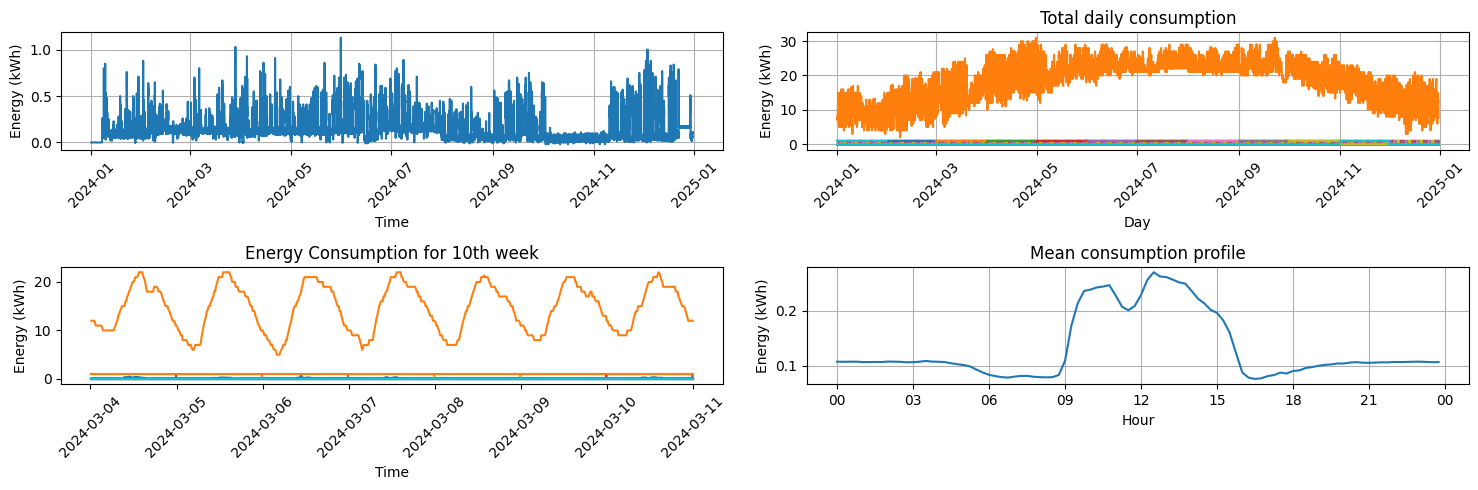

In [69]:
fig = plt.figure(figsize=(15, 5))

ax1 = fig.add_subplot(2, 2, 1)
ax2 = fig.add_subplot(2, 2, 2)
ax3 = fig.add_subplot(2, 2, 3)
ax4 = fig.add_subplot(2, 2, 4)

plot_data(ax1,df2)
temp_df = calculate_daily_consumption(df2)
print(temp_df)
plot_daily_consumption(ax2,df2)
plot_single_week(10,df2,ax3)

temp_df = calculate_mean_profile(df2)
plot_mean_profile(ax4, temp_df)

plt.tight_layout()
plt.show()


3.2 Visualizing distributions of energy consumption
While it is very interesting to observe the evolution of energy consumption over time, it can also be informative to analyze how often how much energy is consumed, i.e. the histogram of the values in the time series.

In most cases, consumption is very low and the distribution falls off rapidly as energy increases. However, there are peaks in the distribution that indicate recurring measurements with the same energy. These are indications of regularly running devices (see later section in the context of pre-processing).

Plotting the distribution with a logarithmic scale of the y-axis reveals peaks with lower counts at higher energy.

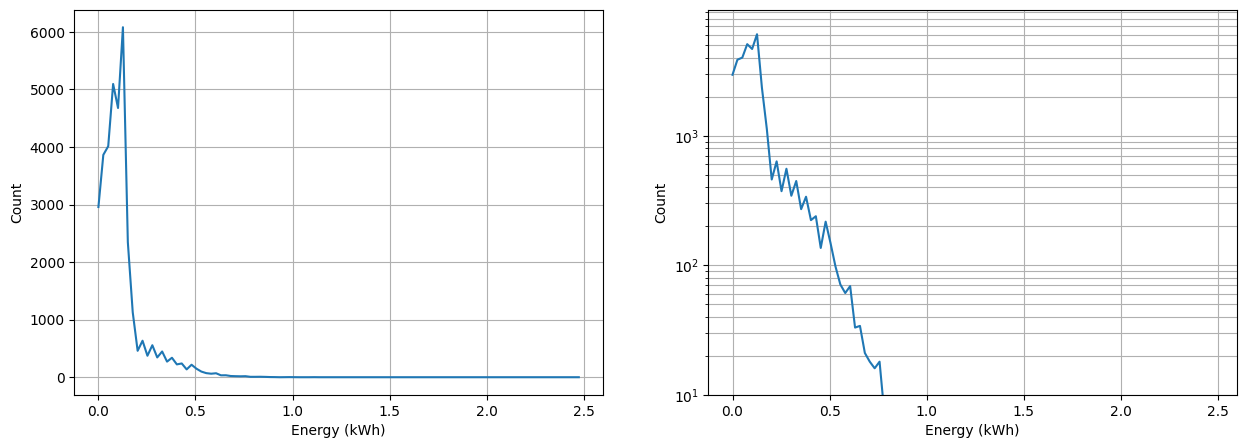

In [71]:
# define the energy intervals to use for the histogram
bins = np.linspace(0, 2.5, 100)

# calculate the distribution of energy values
df2_hist, _ = np.histogram(df2['Load_consumed (kWh)'], bins=bins)

# define a figure with two columns
fig, ax = plt.subplots(1, 2, figsize=(15, 5))

# plot the histogram
ax[0].plot(bins[:-1], df2_hist)
ax[0].set_xlabel('Energy (kWh)')
ax[0].set_ylabel('Count')
ax[0].grid()

# plot the histogram on a logarithmic scale
ax[1].plot(bins[:-1], df2_hist)
ax[1].set_yscale('log')
ax[1].set_ylim(10, None)
ax[1].set_xlabel('Energy (kWh)')
ax[1].set_ylabel('Count')
ax[1].grid(which='both')

# MultiDimension Visualization

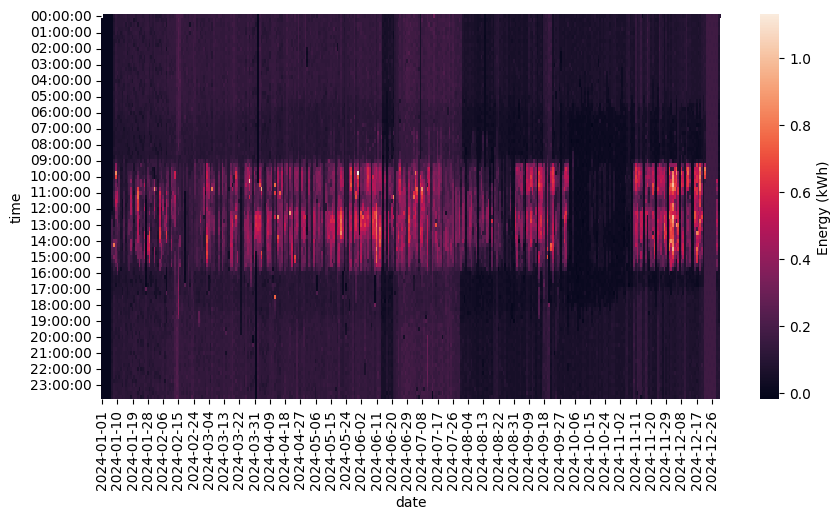

In [74]:

def create_heatmap(df, column, interval_minutes=15):
  # As we will add additional columns and do not want the original data to be affected, create copy of the original data frame
  data_df = df.copy()
  # Add columns for date and time
  data_df["date"] = df.index.date
  data_df["time"] = df.index.time
  # Define a function that handles duplicate values which can occur in local time due to daylight savings time
  # Using only the first datapoint instead of summing avoids unrealistically height demand
  get_first = lambda x: x.iloc[0]

  data = data_df.pivot_table(index='time', columns='date', values=column, aggfunc=get_first, dropna=False)
  return data


hm = create_heatmap(df2, column='Load_consumed (kWh)')

fig_hm, ax_hm = plt.subplots(1, 1, figsize=(10, 5))

sns.heatmap(hm, ax=ax_hm, cbar_kws={'label': 'Energy (kWh)'})

fig.show()